## **IMPORT LIBRARIES AND CREATE DATABASE CONNECTION**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Data path
path = r"C:\Users\ACER\Downloads\data"

print("="*80)
print("CUSTOMER RFM ANALYSIS - DATABASE CONNECTION SETUP")
print("="*80)

# Create SQLite engine
engine = create_engine(f'sqlite:///{path}/sales_analysis.db')

# Create connection from engine
conn = engine.connect()

print("✓ Database engine created successfully")
print("✓ Connection established")

CUSTOMER RFM ANALYSIS - DATABASE CONNECTION SETUP
✓ Database engine created successfully
✓ Connection established


**Achievements**:

    ✓ Imported required libraries
    ✓ Created SQLite database engine
    ✓ Established database connection


## **LOAD DATA INTO DATABASE**

In [2]:
print("\n" + "="*80)
print("LOADING DATA INTO DATABASE")
print("="*80)

# Load CSV files
orders = pd.read_csv(f'{path}/orders.csv')
order_items = pd.read_csv(f'{path}/order_items.csv')
customers = pd.read_csv(f'{path}/customers.csv')

# Convert date columns
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Load data into SQLite database
orders.to_sql('orders', conn, if_exists='replace', index=False)
order_items.to_sql('order_items', conn, if_exists='replace', index=False)
customers.to_sql('customers', conn, if_exists='replace', index=False)

print("✓ Orders table loaded:", orders.shape)
print("✓ Order Items table loaded:", order_items.shape)
print("✓ Customers table loaded:", customers.shape)


LOADING DATA INTO DATABASE
✓ Orders table loaded: (5000, 9)
✓ Order Items table loaded: (5000, 4)
✓ Customers table loaded: (2500, 11)


**Achievements**:

    ✓ Loaded all CSV files
    ✓ Converted date columns to datetime
    ✓ Loaded all tables into SQLite database


## **CREATE RFM ANALYSIS TABLE USING SQL**

In [3]:
print("\n" + "="*80)
print("CREATING RFM ANALYSIS TABLE USING SQL")
print("="*80)

# Get analysis date from the data
analysis_date_query = pd.read_sql_query(
"""
SELECT MAX(order_date) as max_date FROM orders
""", conn)

analysis_date = pd.to_datetime(analysis_date_query['max_date'].iloc[0]) + pd.Timedelta(days=1)
print(f"Analysis Date: {analysis_date.date()}")

# Create RFM table using SQL with CTEs
customer_rfm_data = pd.read_sql_query(
"""
WITH 
order_sales AS (
    SELECT 
        o.order_id,
        o.customer_id,
        o.order_date,
        oi.quantity,
        oi.unit_price,
        (oi.quantity * oi.unit_price) as total_sales
    FROM orders o
    INNER JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_date IS NOT NULL
),
customer_metrics AS (
    SELECT 
        customer_id,
        MAX(order_date) as last_order_date,
        COUNT(DISTINCT order_id) as frequency,
        SUM(total_sales) as monetary
    FROM order_sales
    GROUP BY customer_id
)
-- Final select to make RFM summary table
SELECT 
    customer_id,
    last_order_date,
    frequency,
    monetary
FROM customer_metrics
WHERE customer_id IS NOT NULL
ORDER BY monetary DESC
""", conn)

print("\n✓ Customer RFM table created successfully")
print(f"Shape: {customer_rfm_data.shape}")
print(f"\nColumns: {list(customer_rfm_data.columns)}")
print(f"\nFirst rows:")
print(customer_rfm_data.head(10))


CREATING RFM ANALYSIS TABLE USING SQL
Analysis Date: 2024-11-05

✓ Customer RFM table created successfully
Shape: (2172, 4)

Columns: ['customer_id', 'last_order_date', 'frequency', 'monetary']

First rows:
   customer_id             last_order_date  frequency  monetary
0     25128143  2024-01-27 20:17:00.000000          7  10533.39
1     77869660  2024-09-08 06:29:00.000000          9  10115.75
2     12272282  2024-10-07 14:03:00.000000          5   9924.84
3      4597433  2024-08-26 16:17:00.000000          6   9553.69
4     33331259  2024-06-11 01:55:00.000000          4   9403.77
5     14472401  2024-06-24 19:15:00.000000          4   9275.73
6     85561151  2024-01-10 05:24:00.000000          4   9268.59
7     22800586  2024-03-06 18:58:00.000000          4   9237.24
8     34668988  2024-09-27 02:18:00.000000          4   9160.73
9     13760839  2024-06-10 02:03:00.000000          5   9113.99


**Achievements**:

    ✓ Created SQL query with CTEs for RFM calculation
    ✓ Joined orders and order_items tables
    ✓ Calculated frequency and monetary values in SQL
    ✓ Filtered null customer IDs


## **CALCULATE RFM METRICS**

In [4]:
# Convert last_order_date to datetime
customer_rfm_data['last_order_date'] = pd.to_datetime(customer_rfm_data['last_order_date'])

# Calculate Recency
customer_rfm_data['recency'] = (analysis_date - customer_rfm_data['last_order_date']).dt.days

# Create final RFM dataframe
rfm = customer_rfm_data[['customer_id', 'recency', 'frequency', 'monetary']].copy()

print("="*80)
print("RFM METRICS CALCULATED")
print("="*80)
print(rfm.head(10))
print(f"\nTotal Customers: {len(rfm)}")


RFM METRICS CALCULATED
   customer_id  recency  frequency  monetary
0     25128143      283          7  10533.39
1     77869660       58          9  10115.75
2     12272282       29          5   9924.84
3      4597433       71          6   9553.69
4     33331259      147          4   9403.77
5     14472401      134          4   9275.73
6     85561151      300          4   9268.59
7     22800586      244          4   9237.24
8     34668988       39          4   9160.73
9     13760839      148          5   9113.99

Total Customers: 2172


In [5]:
# RFM Statistics
print("\n" + "="*80)
print("RFM STATISTICS")
print("="*80)
print(rfm[['recency', 'frequency', 'monetary']].describe())

print(f"\nRecency:")
print(f"  Min: {rfm['recency'].min()} days")
print(f"  Max: {rfm['recency'].max()} days")
print(f"  Mean: {rfm['recency'].mean():.1f} days")

print(f"\nFrequency:")
print(f"  Min: {rfm['frequency'].min()} orders")
print(f"  Max: {rfm['frequency'].max()} orders")
print(f"  Mean: {rfm['frequency'].mean():.1f} orders")

print(f"\nMonetary:")
print(f"  Min: ${rfm['monetary'].min():.2f}")
print(f"  Max: ${rfm['monetary'].max():.2f}")
print(f"  Mean: ${rfm['monetary'].mean():.2f}")


RFM STATISTICS
           recency    frequency      monetary
count  2172.000000  2172.000000   2172.000000
mean    207.266114     2.302026   2289.325704
std     156.384290     1.246990   1713.517602
min       1.000000     1.000000     12.320000
25%      74.000000     1.000000    919.787500
50%     171.000000     2.000000   1959.980000
75%     316.250000     3.000000   3225.060000
max     600.000000     9.000000  10533.390000

Recency:
  Min: 1 days
  Max: 600 days
  Mean: 207.3 days

Frequency:
  Min: 1 orders
  Max: 9 orders
  Mean: 2.3 orders

Monetary:
  Min: $12.32
  Max: $10533.39
  Mean: $2289.33


**Achievements:**

    ✓ Calculated Recency (days since last purchase)
    ✓ Extracted Frequency from SQL query (number of orders)
    ✓ Extracted Monetary from SQL query (total revenue)
    ✓ Generated RFM statistics summary


## **RFM SCORING**

In [6]:
# Create RFM scores (1-4 scale)
rfm['r_score'] = pd.qcut(rfm['recency'], 4, labels=[4, 3, 2, 1])  # Lower recency = better
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])  # Higher frequency = better
rfm['m_score'] = pd.qcut(rfm['monetary'], 4, labels=[1, 2, 3, 4])  # Higher monetary = better

# Convert to numeric
rfm['r_score'] = rfm['r_score'].astype(int)
rfm['f_score'] = rfm['f_score'].astype(int)
rfm['m_score'] = rfm['m_score'].astype(int)

# Create RFM Score
rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

# Create RFM Segment String
rfm['rfm_segment'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

print("="*80)
print("RFM SCORING COMPLETED")
print("="*80)
print(rfm.head(10))
print(f"\nRFM Score Range: {rfm['rfm_score'].min()} to {rfm['rfm_score'].max()}")
print(f"\nScore Distribution:")
print(rfm['rfm_score'].value_counts().sort_index())

RFM SCORING COMPLETED
   customer_id  recency  frequency  monetary  r_score  f_score  m_score  \
0     25128143      283          7  10533.39        2        4        4   
1     77869660       58          9  10115.75        4        4        4   
2     12272282       29          5   9924.84        4        4        4   
3      4597433       71          6   9553.69        4        4        4   
4     33331259      147          4   9403.77        3        4        4   
5     14472401      134          4   9275.73        3        4        4   
6     85561151      300          4   9268.59        2        4        4   
7     22800586      244          4   9237.24        2        4        4   
8     34668988       39          4   9160.73        4        4        4   
9     13760839      148          5   9113.99        3        4        4   

   rfm_score rfm_segment  
0         10         244  
1         12         444  
2         12         444  
3         12         444  
4         11     

**Achievements:**

    ✓ Created RFM scores using quartile method
    ✓ Generated individual R, F, M scores (1-4 scale)
    ✓ Created combined RFM score (3-12 range)
    ✓ Created RFM segment identifiers


## **CUSTOMER SEGMENTATION**

In [7]:
# Define customer segments
def segment_customer(row):
    if row['rfm_score'] >= 9:
        return 'Champions'
    elif row['rfm_score'] >= 7:
        return 'Loyal Customers'
    elif row['rfm_score'] >= 5:
        return 'Potential Loyalists'
    elif row['rfm_score'] >= 4 and row['r_score'] >= 3:
        return 'At Risk'
    elif row['rfm_score'] >= 4:
        return 'Need Attention'
    else:
        return 'Lost'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

print("="*80)
print("CUSTOMER SEGMENTATION COMPLETED")
print("="*80)
print(rfm[['customer_id', 'recency', 'frequency', 'monetary', 'rfm_score', 'segment']].head(10))

CUSTOMER SEGMENTATION COMPLETED
   customer_id  recency  frequency  monetary  rfm_score    segment
0     25128143      283          7  10533.39         10  Champions
1     77869660       58          9  10115.75         12  Champions
2     12272282       29          5   9924.84         12  Champions
3      4597433       71          6   9553.69         12  Champions
4     33331259      147          4   9403.77         11  Champions
5     14472401      134          4   9275.73         11  Champions
6     85561151      300          4   9268.59         10  Champions
7     22800586      244          4   9237.24         10  Champions
8     34668988       39          4   9160.73         12  Champions
9     13760839      148          5   9113.99         11  Champions


In [8]:
# Segment distribution
segment_summary = rfm.groupby('segment').agg({
    'customer_id': 'count',
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'sum'
}).reset_index()

segment_summary.columns = ['segment', 'customer_count', 'avg_recency', 'avg_frequency', 'total_revenue']
segment_summary['revenue_percent'] = (segment_summary['total_revenue'] / segment_summary['total_revenue'].sum() * 100)
segment_summary = segment_summary.sort_values('total_revenue', ascending=False)

print("\n" + "="*80)
print("SEGMENT SUMMARY")
print("="*80)
print(segment_summary)


SEGMENT SUMMARY
               segment  customer_count  avg_recency  avg_frequency  \
0            Champions             833    99.460984       3.458583   
2      Loyal Customers             527   184.362429       2.098672   
4  Potential Loyalists             455   272.758242       1.441758   
3       Need Attention             229   385.951965       1.000000   
1                 Lost             128   450.656250       1.000000   

   total_revenue  revenue_percent  
0     3052808.53        61.394881  
2     1057798.43        21.273332  
4      594950.80        11.965026  
3      187201.66         3.764803  
1       79656.01         1.601958  


**Achievements:**

    ✓ Created customer segments based on RFM scores
    ✓ Defined 6 customer segments
    ✓ Calculated segment-wise statistics
    ✓ Computed revenue contribution by segment


## **SEGMENT DISTRIBUTION VISUALIZATIONS**

In [9]:
print("\n" + "="*80)
print("SEGMENT DISTRIBUTION ANALYSIS")
print("="*80)
print(f"Total Segments: {rfm['segment'].nunique()}")
print(f"Segment Distribution:")
print(rfm['segment'].value_counts())


SEGMENT DISTRIBUTION ANALYSIS
Total Segments: 5
Segment Distribution:
segment
Champions              833
Loyal Customers        527
Potential Loyalists    455
Need Attention         229
Lost                   128
Name: count, dtype: int64


## **Customer Distribution by Segment Visualization**

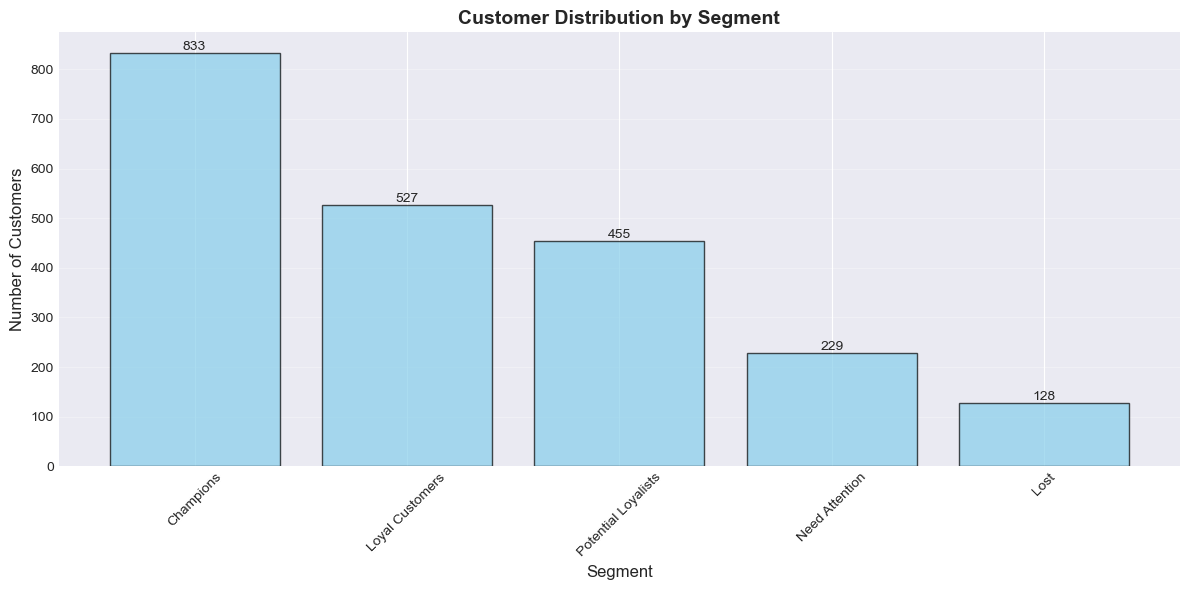

In [10]:
plt.figure(figsize=(12, 6))
plt.bar(segment_summary['segment'], segment_summary['customer_count'], color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Customer Distribution by Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(segment_summary['customer_count']):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## **Total Revenue by Segment Visualization**

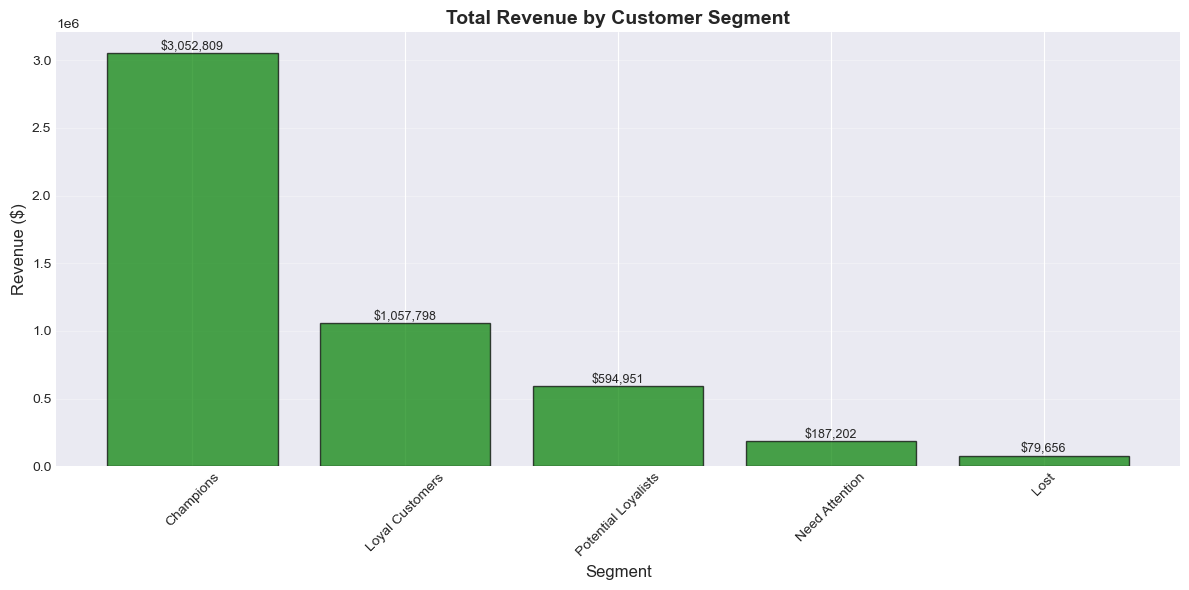

In [11]:
plt.figure(figsize=(12, 6))
plt.bar(segment_summary['segment'], segment_summary['total_revenue'], color='green', edgecolor='black', alpha=0.7)
plt.title('Total Revenue by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(segment_summary['total_revenue']):
    plt.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## **Customer Distribution Pie Chart**

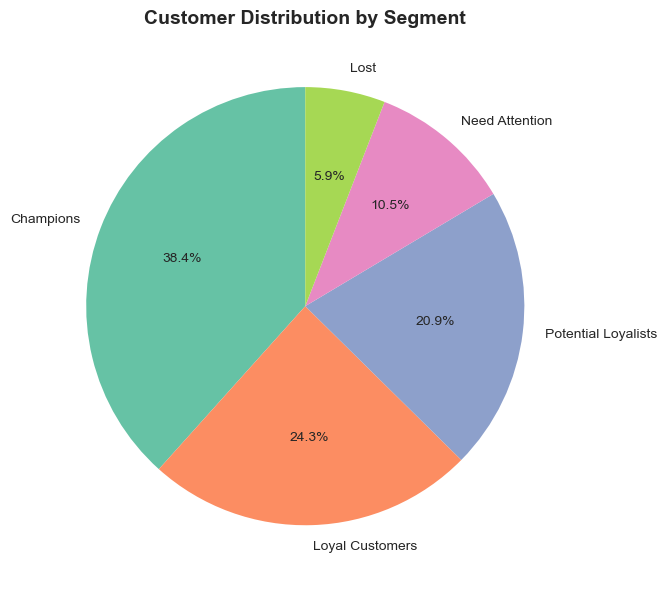

In [13]:
plt.figure(figsize=(10, 6))
plt.pie(segment_summary['customer_count'], labels=segment_summary['segment'], autopct='%1.1f%%', startangle=90)
plt.title('Customer Distribution by Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **Revenue Distribution Pie Chart**

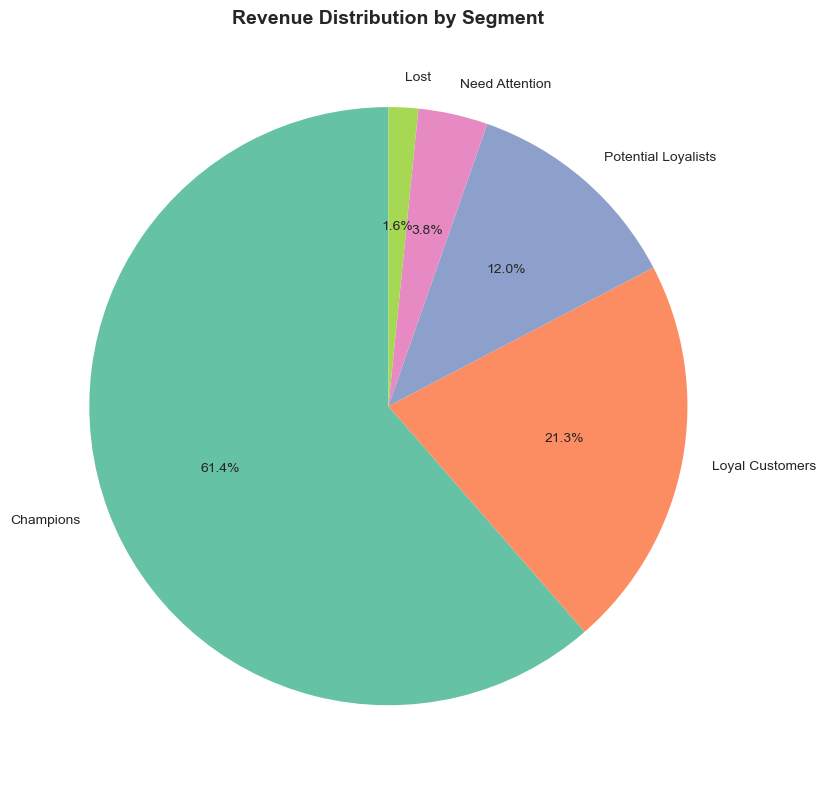

In [16]:
plt.figure(figsize=(10, 8))
plt.pie(segment_summary['total_revenue'], labels=segment_summary['segment'], autopct='%1.1f%%', startangle=90)
plt.title('Revenue Distribution by Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Achievements:**

    ✓ Visualized customer distribution across segments
    ✓ Showed revenue contribution by segment
    ✓ Created pie charts for segment proportions
    ✓ Highlighted segment importance


## **RFM DISTRIBUTION ANALYSIS**

In [18]:
print("="*80)
print("RFM METRICS DISTRIBUTION ANALYSIS")
print("="*80)
print(f"Recency Distribution:")
print(f"  0-30 days: {len(rfm[rfm['recency'] <= 30])} customers")
print(f"  31-60 days: {len(rfm[(rfm['recency'] > 30) & (rfm['recency'] <= 60)])} customers")
print(f"  61-90 days: {len(rfm[(rfm['recency'] > 60) & (rfm['recency'] <= 90)])} customers")
print(f"  90+ days: {len(rfm[rfm['recency'] > 90])} customers")

print(f"\nFrequency Distribution:")
print(f"  1 order: {len(rfm[rfm['frequency'] == 1])} customers")
print(f"  2-3 orders: {len(rfm[(rfm['frequency'] >= 2) & (rfm['frequency'] <= 3)])} customers")
print(f"  4-5 orders: {len(rfm[(rfm['frequency'] >= 4) & (rfm['frequency'] <= 5)])} customers")
print(f"  6+ orders: {len(rfm[rfm['frequency'] >= 6])} customers")

RFM METRICS DISTRIBUTION ANALYSIS
Recency Distribution:
  0-30 days: 237 customers
  31-60 days: 218 customers
  61-90 days: 181 customers
  90+ days: 1536 customers

Frequency Distribution:
  1 order: 680 customers
  2-3 orders: 1137 customers
  4-5 orders: 316 customers
  6+ orders: 39 customers


## **Recency Distribution Visualization**

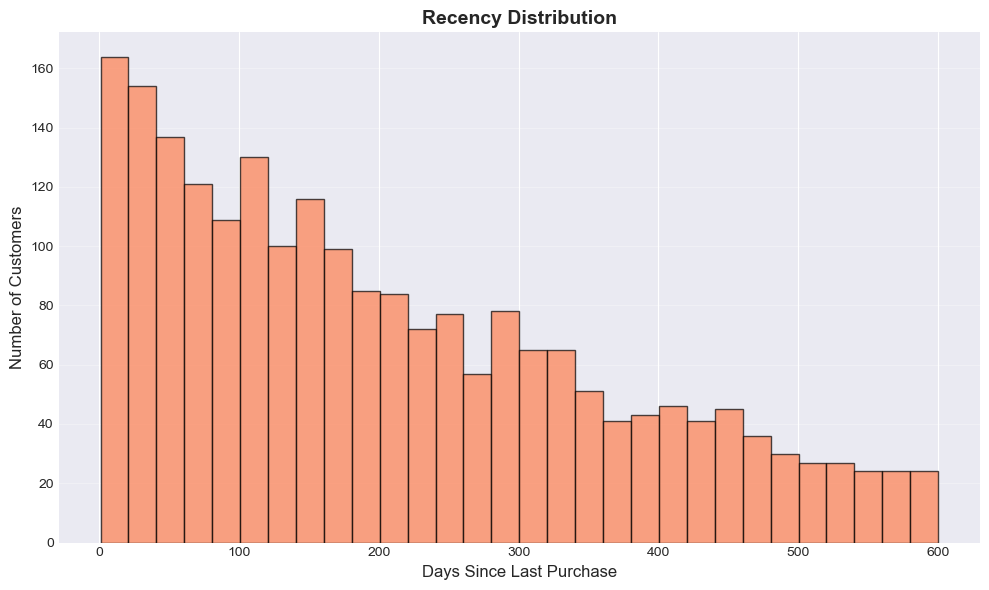

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(rfm['recency'], bins=30, color='coral', edgecolor='black', alpha=0.7)
plt.title('Recency Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Days Since Last Purchase', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## **Frequency Distribution Visualization**

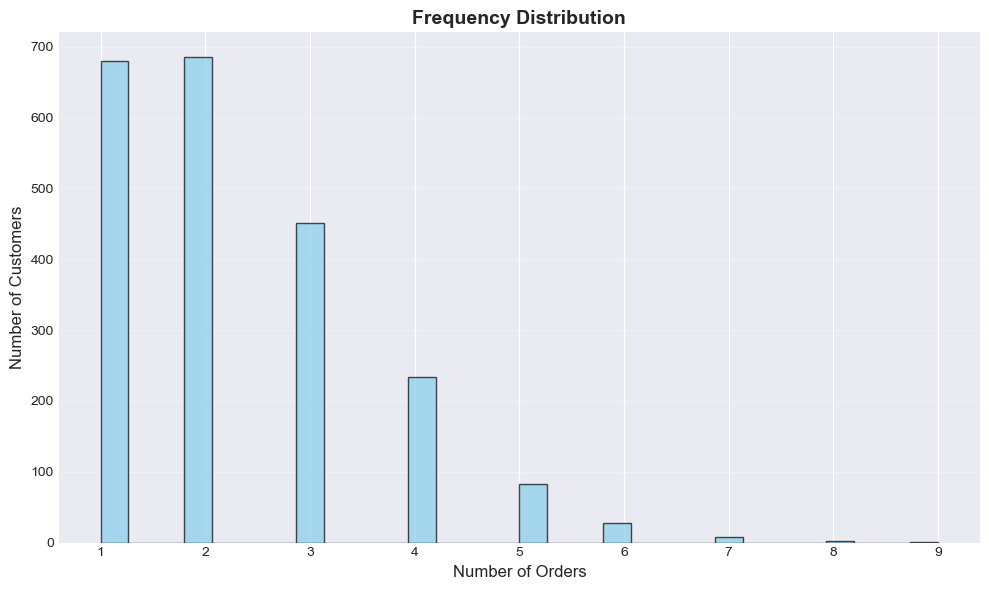

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(rfm['frequency'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Frequency Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Orders', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## **Monetary Distribution Visualization**

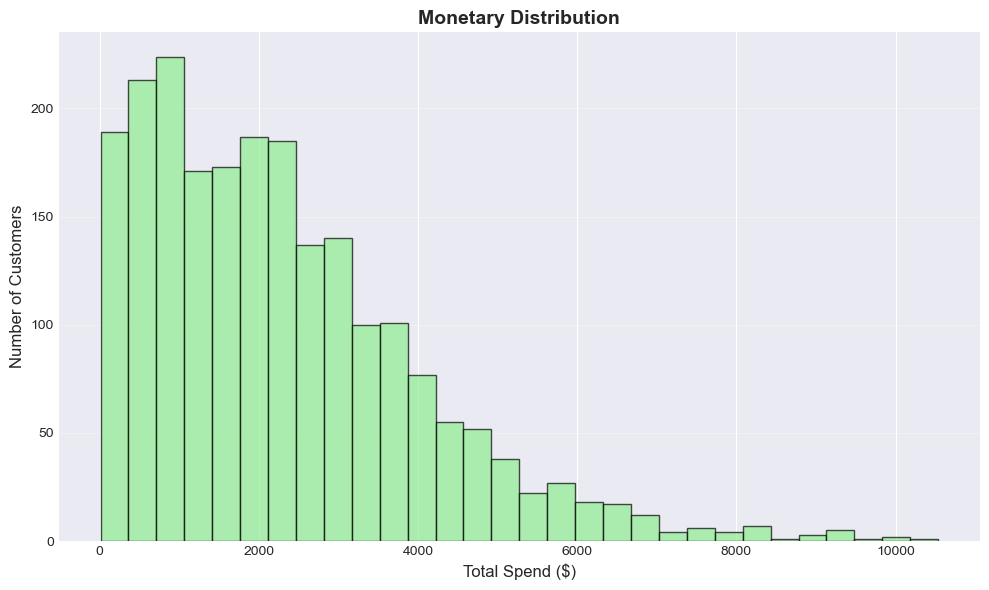

In [21]:
plt.figure(figsize=(10, 6))
plt.hist(rfm['monetary'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
plt.title('Monetary Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Total Spend ($)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [29]:
# Top customers by RFM score
top_customers = rfm.sort_values('rfm_score', ascending=False).head(20)

print("="*80)
print("TOP 20 CUSTOMERS BY RFM SCORE")
print("="*80)
print(top_customers[['customer_id', 'recency', 'frequency', 'monetary', 'rfm_score', 'segment']])


TOP 20 CUSTOMERS BY RFM SCORE
     customer_id  recency  frequency  monetary  rfm_score    segment
46      42208242        9          4   6675.09         12  Champions
3        4597433       71          6   9553.69         12  Champions
44      51476157        1          4   6690.86         12  Champions
346     77007315       66          4   3893.44         12  Champions
40      13251137       72          5   6790.44         12  Champions
39       8791577       22          8   6844.42         12  Champions
67      18791381       15          4   6209.40         12  Champions
63      90448312        2          6   6311.52         12  Champions
62      29562072        3          4   6386.57         12  Champions
60      96989204       59          4   6412.81         12  Champions
26      21701991       62          7   7437.17         12  Champions
2       12272282       29          5   9924.84         12  Champions
351     48418662       20          4   3872.41         12  Champions
350 

In [23]:
# Top customers by monetary value
top_monetary = rfm.sort_values('monetary', ascending=False).head(10)

print("\n" + "="*80)
print("TOP 10 CUSTOMERS BY REVENUE")
print("="*80)
print(top_monetary[['customer_id', 'recency', 'frequency', 'monetary', 'segment']])
print(f"\nTop 10 Revenue: ${top_monetary['monetary'].sum():,.2f}")
print(f"Percentage of Total: {top_monetary['monetary'].sum()/rfm['monetary'].sum()*100:.1f}%")


TOP 10 CUSTOMERS BY REVENUE
   customer_id  recency  frequency  monetary    segment
0     25128143      283          7  10533.39  Champions
1     77869660       58          9  10115.75  Champions
2     12272282       29          5   9924.84  Champions
3      4597433       71          6   9553.69  Champions
4     33331259      147          4   9403.77  Champions
5     14472401      134          4   9275.73  Champions
6     85561151      300          4   9268.59  Champions
7     22800586      244          4   9237.24  Champions
8     34668988       39          4   9160.73  Champions
9     13760839      148          5   9113.99  Champions

Top 10 Revenue: $95,587.72
Percentage of Total: 1.9%


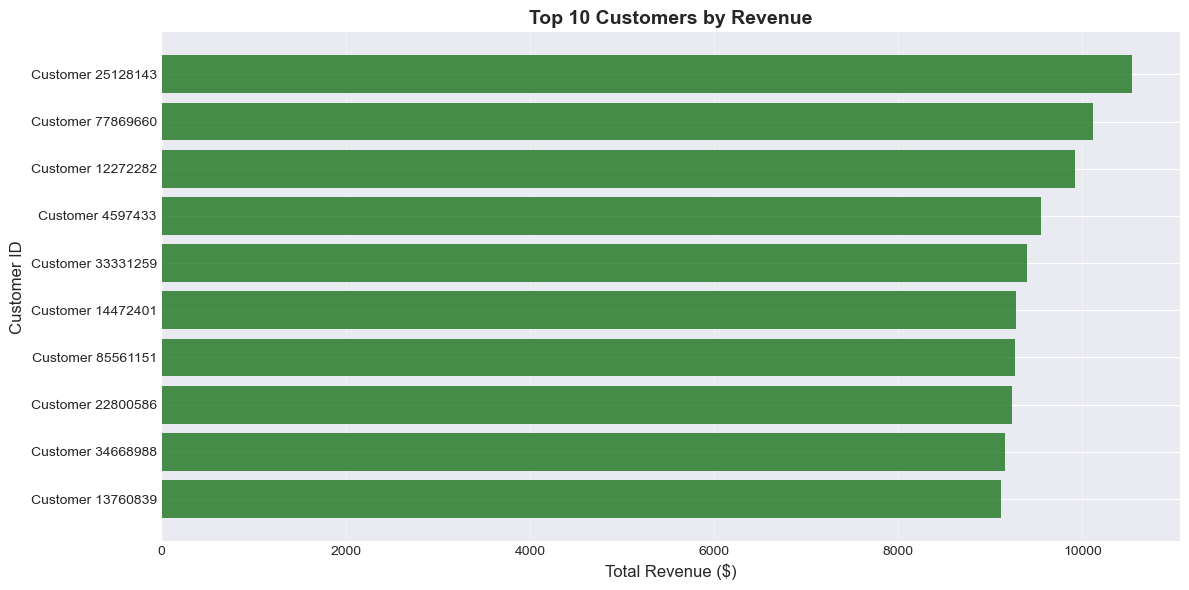

In [24]:
plt.figure(figsize=(12, 6))
plt.barh(range(10), top_monetary['monetary'].head(10), color='darkgreen', alpha=0.7)
plt.yticks(range(10), [f'Customer {id}' for id in top_monetary['customer_id'].head(10)])
plt.title('Top 10 Customers by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Customer ID', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## **Recency vs Monetary Scatter Plot**

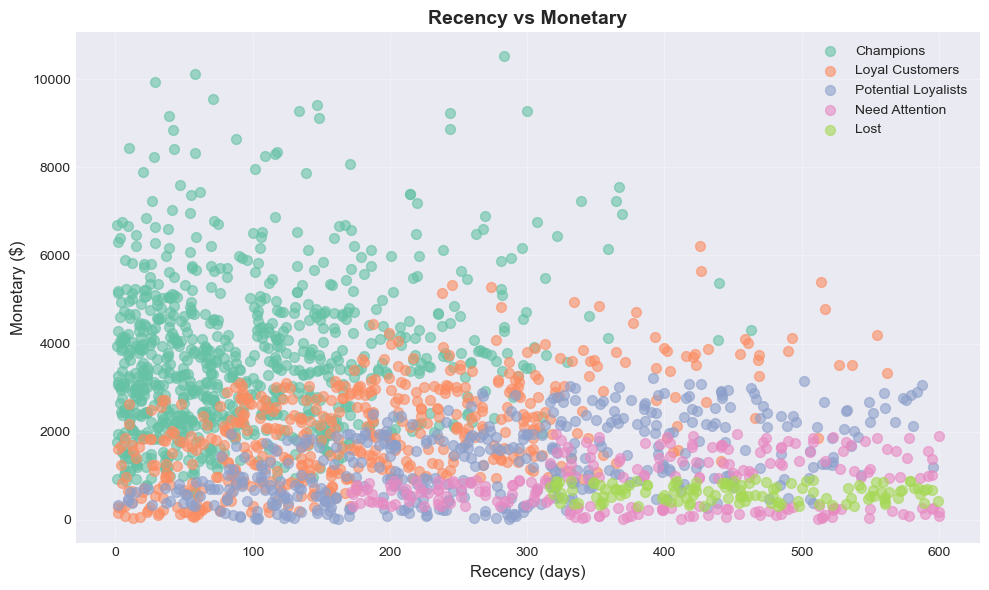

In [25]:
plt.figure(figsize=(10, 6))
for segment in rfm['segment'].unique():
    segment_data = rfm[rfm['segment'] == segment]
    plt.scatter(segment_data['recency'], segment_data['monetary'], label=segment, alpha=0.6, s=50)
plt.title('Recency vs Monetary', fontsize=14, fontweight='bold')
plt.xlabel('Recency (days)', fontsize=12)
plt.ylabel('Monetary ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **Frequency vs Monetary Scatter Plot**

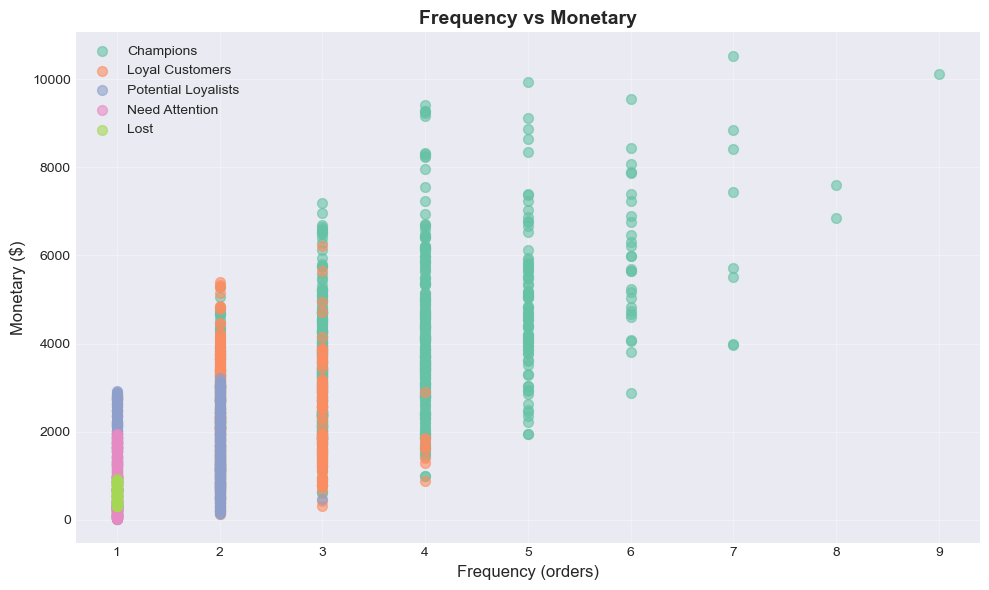

In [26]:
plt.figure(figsize=(10, 6))
for segment in rfm['segment'].unique():
    segment_data = rfm[rfm['segment'] == segment]
    plt.scatter(segment_data['frequency'], segment_data['monetary'], label=segment, alpha=0.6, s=50)
plt.title('Frequency vs Monetary', fontsize=14, fontweight='bold')
plt.xlabel('Frequency (orders)', fontsize=12)
plt.ylabel('Monetary ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **Recency vs Frequency Scatter Plot**

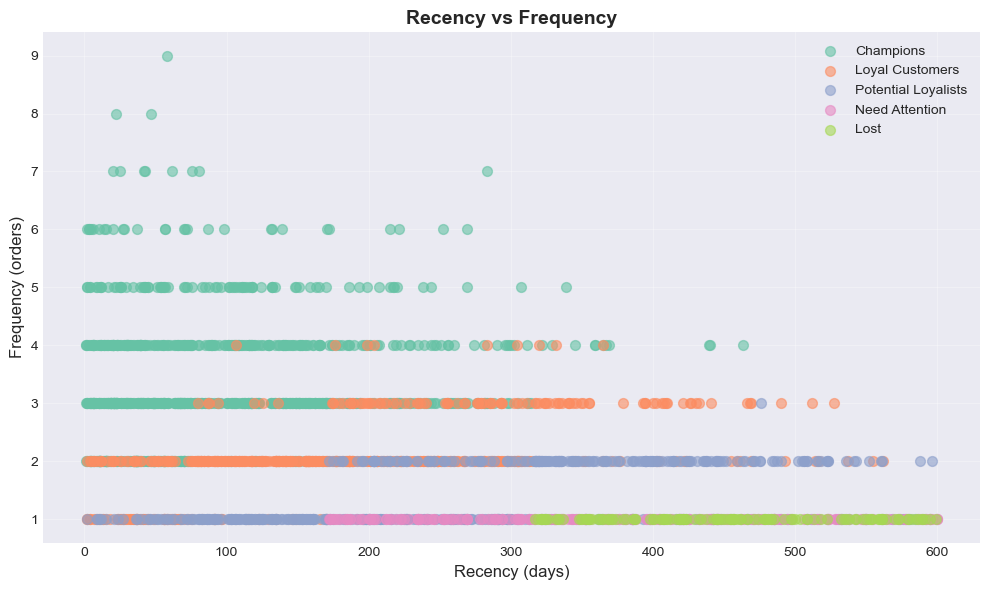

In [27]:
plt.figure(figsize=(10, 6))
for segment in rfm['segment'].unique():
    segment_data = rfm[rfm['segment'] == segment]
    plt.scatter(segment_data['recency'], segment_data['frequency'], label=segment, alpha=0.6, s=50)
plt.title('Recency vs Frequency', fontsize=14, fontweight='bold')
plt.xlabel('Recency (days)', fontsize=12)
plt.ylabel('Frequency (orders)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()